## Preprocessing
#### 0. Loading libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer


df = pd.read_csv("../data/raw/2023-24 RLS Public Use File Feb 19.csv")
df['QB2C_binary'] = df['QB2C'].map({2: 1, 1: 0})
df_binary = df[df['QB2C'] != 99].copy()
df_binary['QB2C_binary'] = df_binary['QB2C'].map({2: 1, 1: 0})

### 1. Missing Values and Range of values
This section is designed to check the quality of attributes for our analysis. Variables with only NAs and high NAs are excluded. Additionally, variables which from a analytical standpoint are unimportant to our analysis are also excluded (e.g. weights for national analysis, IDs, Year of conduction). The final dataframe has 111 columns

#### 1.1 Range of values
- All columns have values in the range of the codebook


#### 1.2 Detecting Missing Values
- 23 variables with 100% missing (sensitive variables) --> dropped
- 14 variables with high shares of missing data due to hierarchical structure
    - PARTYLN (party leaning): only for people not Republican or Democrat (should be included and encoded for those who have answered not dem/rep)
    - LEADRACE & CONGRACE only asked where ATTENDPERRLS != 5, 6 or 99 (attend at least regularly)
    - KIDACT ABC only where CHILDREN == 1 (have children)
    - MARWHENREC, SPRELIMP, SPRELTALK, SPRELSIM, RELMATCH only where MARTIAL == 1 (are married)
    - BORNFINAL only where CURREL isin (1000, 10000, 20000, 30000, 40001, 40002) (are Christian)
    - CHBORNFINAL only where FRMREL isin (1000, 10000, 20000, 30000, 40001, 40002) (are raised as christian)
    - CHCONGRACE (Thinking place attend religious services growingup, race?) where CHATTEND != 5,6,99

- 5 other variables missingness
    - PAR2CHILDA (two parents are better?)
    - HH3REC (how many adults are living in your household)
    - HUMNTR_A, HUMNTR_B (God gave humans right to use/duty to protect earth?)
    - GOD2 (How certain are you in your belief) (not high, should be included)

In [2]:
#Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

##columns with 100% missing 
complete_missing = missing_df[missing_df['missing_pct'] == 100]
print(f"\nColumns with 100% missing: {len(complete_missing)}")
print(complete_missing.index.tolist())

#removing columns with 100% missing
missing_df = missing_df.loc[missing_df["missing_pct"] != 100]

##Columns with missing values
#Printing
print(f"\nOther columns with missing values: {len(missing_df)}")
print(f"Columns by missing %:")
print(missing_df.tail(20))



Columns with 100% missing: 23
['REGION', 'DENOMREC2', 'FAMILY', 'CURREL2', 'PROTFAM', 'KIDS4ANDUNDERREC', 'KIDS13TO17REC', 'SPREL', 'SPREL2', 'SPBORNFINAL', 'FRMREL2', 'WEIGHT_MSA', 'MSA', 'YEARSINUSREC', 'ORIENTMOD', 'BRANCH', 'BIRTHHALFDECADE', 'KIDS5TO12REC', 'STATE', 'MOTHER_BIRTHREGION', 'FATHER_BIRTHREGION', 'RESPONDENT_BIRTHREGION', 'CITIZEN']

Other columns with missing values: 20
Columns by missing %:
             missing_count  missing_pct
KIDACT_C             28589        77.46
KIDACT_B             28589        77.46
KIDACT_A             28589        77.46
PARTYLN              22654        61.38
CONGRACE             18583        50.35
LEADRACE             18583        50.35
MARWHENREC           17999        48.77
PAR2CHILDA           17232        46.69
RELMATCH             15094        40.90
SPRELIMP             15094        40.90
SPRELTALK            15094        40.90
SPRELSIM             15094        40.90
BORNFINAL            13722        37.18
HH3REC               1027

#### 1.2 Investigating Hierarchical variables
- LEADRACE only asked where ATTENDPERRLS != 5, 6 or 99
- KIDACT ABC only where CHILDREN == 1
- MARWHENREC, SPRELIMP, SPRELTALK, SPRELSIM, RELMATCH only where MARTIAL == 1
- BORNFINAL only where CURREL isin (1000, 10000, 20000, 30000, 40001, 40002)
- CHBORNFINAL only where FRMREL isin (1000, 10000, 20000, 30000, 40001, 40002)
- No hierarchy for
    - CHCONGRACE, should be excluded

In [3]:
#### KIDACT ABD only when CHILDREN == 1
count_grid = pd.crosstab(df_binary['CHBORNFINAL'], df_binary['FRMREL'], dropna=False)
print(count_grid)

FRMREL       1000    10000   20000   30000   40001   40002   50000   60000   \
CHBORNFINAL                                                                   
1.0            7669    1017     101      29      18      36       0       0   
2.0            9467    9781     607     224     113     164       0       0   
98.0             36      15       0       1      20      27       0       0   
99.0            339     251      10       7       3       7       0       0   
NaN               0       0       0       0       0       0     955     284   

FRMREL       70000   80000   90001   90002   100000  900000  
CHBORNFINAL                                                  
1.0               0       0       0       0       0       0  
2.0               0       0       0       0       0       0  
98.0              0       0       0       0       0       0  
99.0              0       0       0       0       0       0  
NaN             334     278      49     100    3872     311  


In [4]:
##Removing columns
missing_columns = complete_missing.index.tolist()
missing_columns = missing_columns + missing_df.index.tolist()
missing_columns.remove("GOD2")      # low share of NAs, (1.53%), hence included
missing_columns.remove("PARTYLN")   # later included in PARTY
missing_columns.remove("HUMNTR_A")  # keep for stewardship theology index
missing_columns.remove("HUMNTR_B")  # keep for stewardship theology index

exclude_cols = (
    missing_columns # columns with high shares of NAs
    + [c for c in df.columns if c.startswith('REPWT')]+ ["WEIGHT", "P_SUID", "YEAR_FROM_CODATE"])

df_clean = df.drop (columns = exclude_cols)
print(df_clean.shape)

(36908, 113)


##### 2.1 Checking for duplicates

In [5]:

duplicates = df_clean[df_clean.duplicated(subset=df_clean.columns[1:], keep=False)]
print(duplicates)

       HAPPY  SATIS_A  SATIS_B  CHNG_A  CHNG_B  CHNG_C  DIVRELPOP  DIVRACPOP  \
11733      1        1        1       1       1       1          1          1   
32119      1        1        1       1       1       1          1          1   

       QB2A  QB2C  ...  MOVED  REG  PARTY  PARTYLN  IDEO  HH1REC  INTFREQ  \
11733     1     2  ...      2    1      3      2.0     3       1        3   
32119     1     2  ...      2    1      3      2.0     3       1        3   

       INC_SDT1  GENDER  FERTREC  
11733         4       1        0  
32119         4       1        0  

[2 rows x 113 columns]


### 2. Recoding Hierarchical Variables

#### 2.1 Recode into parent variable

**UNAFFILDETAIL into RELTRAD**

- Check if all participants that answered `UNAFFILDETAIL` selected *"Religiously unaffiliated" (100000)* in `RELTRAD` → ✅ Yes  

- Prefer using `CURREL` over `RELTRAD`  
  - In `CURREL`, Protestant subgroups (split in `RELTRAD`) are combined into *"Protestant"*  
  - Check if all participants with *"unaffiliated" (100000)* in `RELTRAD` also have it in `CURREL` → ✅ Yes  


---

##### Encoding of new variable: `CURREL_NEW`

<small>


| Code   | Category                                                  |
|--------|-----------------------------------------------------------|
| 1000   | Protestant                                                |
| 10000  | Catholic                                                  |
| 20000  | Church of Jesus Christ of Latter-day Saints (Mormon)      |
| 30000  | Orthodox Christian                                        |
| 40001  | Jehovah's Witness                                         |
| 40002  | Other Christian                                           |
| 50000  | Jewish                                                    |
| 60000  | Muslim                                                    |
| 70000  | Buddhist                                                  |
| 80000  | Hindu                                                     |
| 90001  | Other world religions                                     |
| 90002  | Other faiths                                              |
| 100001 | Religiously unaffiliated (not specified)                  |
| 100002 | Atheist (unaffiliated)                                    |
| 100003 | Agnostic (unaffiliated)                                   |
| 900000 | Refused / uninterpretable                                 |

</small>


In [6]:
print(df_clean[df_clean["UNAFFILDETAIL"].isin([1, 2, 3])]["CURREL"].unique())

[100000]


In [7]:
((df_clean["RELTRAD"] == 100000) <= (df_clean["CURREL"] == 100000)).all()

np.True_

In [8]:
df_clean["CURREL_NEW"] = df_clean["CURREL"]

# Replace unaffiliated with detailed categories

# unspecified
df_clean.loc[(df_clean["CURREL"] == 100000) & (df_clean["UNAFFILDETAIL"] == 3), 'CURREL_NEW'] = 100001

# atheist
df_clean.loc[(df_clean["CURREL"] == 100000) & (df_clean["UNAFFILDETAIL"] == 1), 'CURREL_NEW'] = 100002

# agnostic
df_clean.loc[(df_clean["CURREL"] == 100000) & (df_clean["UNAFFILDETAIL"] == 2),'CURREL_NEW'] = 100003

In [9]:
# check if it worked
df_clean["CURREL_NEW"].value_counts()

# drop columns CURREL and UNAFFILDETAIL
#df_clean = df_clean.drop(columns=["CURREL", "UNAFFILDETAIL"])

CURREL_NEW
1000      15099
10000      6958
100001     6329
100003     2401
100002     1999
50000       850
90002       761
20000       565
900000      415
70000       348
60000       273
80000       247
40002       226
30000       225
40001       113
90001        99
Name: count, dtype: int64

**PARTYLN into PARTY**

- Check if all participants that answered `PARTYLN` selected  
  *"Independent" (3), "Something else" (4), or "Refuse" (99)* in `PARTY` → ✅ Yes  

---

##### Plan for new variable

<small>
- If `PARTY = Republican (1)` or `Democrat (2)` → keep it  
- If `PARTY = Independent (3)`, `Other (4)`, or `Refuse (99)` → use `PARTYLN` to refine  
- If no leaning → classify as *No Lean*  
- If refusal occurs → classify as *Refuse*  
</small>

---


##### Recoding rules
<small>
- If `PARTY = 1` → `POLITICAL_ATTITUDE = 1` (Republican)  
- If `PARTY = 2` → `POLITICAL_ATTITUDE = 5` (Democrat)  


**For `PARTY ∈ {3, 4}` (Independent / Other):**
- If `PARTYLN = 1` → `POLITICAL_ATTITUDE = 2` (Lean Republican)  
- If `PARTYLN = 2` → `POLITICAL_ATTITUDE = 4` (Lean Democrat)  
- If `PARTYLN = 99` → `POLITICAL_ATTITUDE = 3` (No Lean)  


**For `PARTY = 99` (Refuse):**
- If `PARTYLN = 1` → `POLITICAL_ATTITUDE = 2` (Lean Republican)  
- If `PARTYLN = 2` → `POLITICAL_ATTITUDE = 4` (Lean Democrat)  
- If `PARTYLN = 99` → `POLITICAL_ATTITUDE = 99` (Refused)  
</small>

##### Encoding of new variable: `POLITICAL_ATTITUDE`
<small>

| Code | Category              |
|------|----------------------|
| 1    | Republican           |
| 2    | Lean Republican      |
| 3    | No Lean              |
| 4    | Lean Democrat        |
| 5    | Democrat             |
| 99   | Don't know / Refuse  |
</small>



##### Encoding of new variable: `POLITICAL_ATTITUDE`


In [10]:
print(df[df["PARTYLN"].isin([1, 2])]["PARTY"].unique())

[ 3  4 99]


In [11]:
def combine_party(row):
    party = row["PARTY"]
    lean = row["PARTYLN"]
    
    # Strong identifiers
    if party == 1:
        return 1
    elif party == 2:
        return 5
    
    # Independents / others → check leaning; if no leaning --> 3 (no lean)
    elif party in [3, 4]:
        if lean == 1:
            return 2
        elif lean == 2:
            return 4
        elif lean == 99:
            return 3
    
    # for Refuse / missing --> check leaning; if no leaning --> 99 (refused)
    elif party == 99:
        if lean == 1:
            return 2
        elif lean == 2:
            return 4
        elif lean == 99:
            return 99

In [12]:
df_clean["POLITICAL_ATTITUDE"] = df_clean.apply(combine_party, axis=1)


In [13]:
# Check if it worked
print(df_clean['POLITICAL_ATTITUDE'].unique())
print(df_clean["POLITICAL_ATTITUDE"].value_counts())

[ 1  5  4  3  2 99]
POLITICAL_ATTITUDE
5     12124
1     10530
4      6114
2      5171
3      1932
99     1037
Name: count, dtype: int64


In [14]:
df_clean["POLITICAL_ATTITUDE"].value_counts()

POLITICAL_ATTITUDE
5     12124
1     10530
4      6114
2      5171
3      1932
99     1037
Name: count, dtype: int64

In [15]:
df_clean = df_clean.drop(columns=["PARTY", "PARTYLN"])

### 3. Check range of values and recod Special codes --> NaN (99s, 900000 etc.)
- All values are values of the codebook
- Recoding special codes for 104 columns

##### 3.1 Checking range of values

In [23]:
# Range of values
freq_list = []

#For loop
for col in df.columns:
    if col in ["P_SUID", "WEIGHT"] or col.startswith("REPWT"):
        continue
    else:
        counts = df[col].value_counts(dropna=False).reset_index()

        counts.columns = ['Value', 'Count']
        counts['Share'] = (counts['Count'] / len(df))
      
        counts['Variable'] = col

        freq_list.append(counts)

#Combine
df_frequencies = pd.concat(freq_list, ignore_index=True)

#Reordering
df_frequencies = df_frequencies[['Variable', 'Value', 'Count', 'Share']]

##### 3.2 Recoding special values

In [62]:
# variable-specific special codes (beyond 99)
special_codes = {
    'CURREL':      [900000],
    'CURREL_NEW':  [900000],
    'RELTRAD':     [900000],
    'FRMREL':      [900000],
    'RACECMB':     [9],
    'CLIM1A':      [77, 99],   # 77=Not sure, 99=Refused
    'POLITICAL_ATTITUDE': [99],
}

for col, codes in special_codes.items():
    if col in df_clean.columns:
        before = df_clean[col].isna().sum()
        df_clean[col] = df_clean[col].replace(codes, np.nan)
        after = df_clean[col].isna().sum()
        print(f"{col}: {after - before} additional NaNs from special codes")

# replace 99 with NaN across all remaining columns (catches any variables not explicitly listed above
cols_with_99 = [col for col in df_clean.columns 
                if df_clean[col].isin([99]).any()]
print(f"\nColumns with remaining 99s before global pass: {len(cols_with_99)}")

for col in cols_with_99:
    df_clean[col] = df_clean[col].replace(99, np.nan)

print("Global 99 → NaN pass complete")

# verify
remaining_99 = [col for col in df_clean.columns 
                if df_clean[col].isin([99]).any()]
print(f"Columns still containing 99: {len(remaining_99)}")

df_clean = df_clean.copy()  

CURREL: 415 additional NaNs from special codes
CURREL_NEW: 415 additional NaNs from special codes
RELTRAD: 415 additional NaNs from special codes
FRMREL: 332 additional NaNs from special codes
RACECMB: 900 additional NaNs from special codes
CLIM1A: 6268 additional NaNs from special codes
POLITICAL_ATTITUDE: 1037 additional NaNs from special codes

Columns with remaining 99s before global pass: 104
Global 99 → NaN pass complete
Columns still containing 99: 0


### 4. Patterns in Question Answering (Straightlining, Attentiveness)
- No one answers only with NA (0 with > 0.5)
- No rows with high share of maximum as answer (0 with > 0.5)
- many rows with high share of minimum as answer (956 with > 0.5)
    - Checking straightlining with RELCON (wouldn't make sense to answer all with minimum), 15 suspicious lines removed


#### 4.1 Straightlining

In [63]:
# Check people only answering "Dont know" (77), "Refused" (99) or NAs
print(df_clean[df_clean.isnull().mean(axis=1) > 0.5])

Empty DataFrame
Columns: [HAPPY, SATIS_A, SATIS_B, CHNG_A, CHNG_B, CHNG_C, DIVRELPOP, DIVRACPOP, QB2A, QB2C, QB2D, OPENIDEN, POORASSIST, GOVSIZE1, ABRTLGL, GAYMARR, PAR2CHILD, CLIM1A, EVOL, GUIDE_A, GUIDE_B, GUIDE_C, GUIDE_D, RELTRAD, CURREL, UNAFFILDETAIL, RELPER, SPIRPER, RELCON_A, RELCON_B, RELCON_C, RELCON_D, RELCON_E, ATTNDPERRLS, ATTNDONRLS, RELIMP, MEMB, GOD, GOD2, HVN, HLL, SOUL, BIBIMP, HUMNTR_A, HUMNTR_B, PRAY, GRACE, PRAC_A, PRAC_B, PRAC_C, PRAC_D, EXP_A, EXP_B, EXP_C, EXP_D, EXP_E, EXP_F, EXP_G, SPIRACT_A, SPIRACT_B, SPIRACT_C, SPIRACT_D, SPIRACT_E, SPIRACT_F, RTRT, SECMEMB, VOL12_CPS, SCIMPACT, RELIMPACT, SCRLCON1, SPIRWORLD2, SECBEL1, SECBEL2, FRMREL, CHIMPREL_A, CHIMPREL_B, CHATTEND, CHEDU1, CHEDU2, LIFEDIR, LIFESPIR, GTHGHT, MARITAL, CHILDREN, RELINST_A, RELINST_B, RELINST_D, RELINST_E, RELINST_F, RELINST_G, SCPRY1, SCPRY2, RELDISP, CHRNAT, BIRTHDECADE, HISP, RACECMB, AFROHISP, EDUCREC, E2, ...]
Index: []

[0 rows x 113 columns]


In [64]:
# Check only answering with max values
is_max = df_clean.apply(lambda row: row == row.max(), axis=1)
print(df_clean[is_max.mean(axis=1) > 0.5])

Empty DataFrame
Columns: [HAPPY, SATIS_A, SATIS_B, CHNG_A, CHNG_B, CHNG_C, DIVRELPOP, DIVRACPOP, QB2A, QB2C, QB2D, OPENIDEN, POORASSIST, GOVSIZE1, ABRTLGL, GAYMARR, PAR2CHILD, CLIM1A, EVOL, GUIDE_A, GUIDE_B, GUIDE_C, GUIDE_D, RELTRAD, CURREL, UNAFFILDETAIL, RELPER, SPIRPER, RELCON_A, RELCON_B, RELCON_C, RELCON_D, RELCON_E, ATTNDPERRLS, ATTNDONRLS, RELIMP, MEMB, GOD, GOD2, HVN, HLL, SOUL, BIBIMP, HUMNTR_A, HUMNTR_B, PRAY, GRACE, PRAC_A, PRAC_B, PRAC_C, PRAC_D, EXP_A, EXP_B, EXP_C, EXP_D, EXP_E, EXP_F, EXP_G, SPIRACT_A, SPIRACT_B, SPIRACT_C, SPIRACT_D, SPIRACT_E, SPIRACT_F, RTRT, SECMEMB, VOL12_CPS, SCIMPACT, RELIMPACT, SCRLCON1, SPIRWORLD2, SECBEL1, SECBEL2, FRMREL, CHIMPREL_A, CHIMPREL_B, CHATTEND, CHEDU1, CHEDU2, LIFEDIR, LIFESPIR, GTHGHT, MARITAL, CHILDREN, RELINST_A, RELINST_B, RELINST_D, RELINST_E, RELINST_F, RELINST_G, SCPRY1, SCPRY2, RELDISP, CHRNAT, BIRTHDECADE, HISP, RACECMB, AFROHISP, EDUCREC, E2, ...]
Index: []

[0 rows x 113 columns]


In [65]:
# Check only answering with min values
is_min = df_clean.apply(lambda row: row == row.min(), axis=1)
sus_rows = (df_clean[is_min.mean(axis=1) > 0.5])
print(sus_rows)

       HAPPY  SATIS_A  SATIS_B  CHNG_A  CHNG_B  CHNG_C  DIVRELPOP  DIVRACPOP  \
64       3.0      3.0      3.0     3.0     3.0     3.0        2.0        3.0   
107      1.0      1.0      1.0     1.0     1.0     2.0        1.0        1.0   
212      1.0      1.0      1.0     1.0     1.0     2.0        1.0        1.0   
225      3.0      1.0      1.0     2.0     1.0     2.0        2.0        3.0   
241      2.0      3.0      3.0     2.0     1.0     2.0        2.0        1.0   
...      ...      ...      ...     ...     ...     ...        ...        ...   
36660    1.0      2.0      3.0     1.0     1.0     2.0        1.0        1.0   
36750    2.0      1.0      1.0     2.0     1.0     2.0        2.0        2.0   
36758    1.0      3.0      1.0     2.0     1.0     2.0        2.0        2.0   
36849    2.0      3.0      4.0     2.0     1.0     2.0        2.0        2.0   
36858    2.0      3.0      4.0     2.0     3.0     2.0        2.0        3.0   

       QB2A  QB2C  ...  MOVED  REG  IDE

In [66]:
#checking straightlining with RELCON variables
df_sus = df_clean.loc[sus_rows.index.tolist(), ['RELCON_A', 'RELCON_B', 'RELCON_C', 'RELCON_D', 'RELCON_E']]
print(df_sus[df_sus.eq(1).all(axis=1)])

       RELCON_A  RELCON_B  RELCON_C  RELCON_D  RELCON_E
4621        1.0       1.0       1.0       1.0       1.0
5486        1.0       1.0       1.0       1.0       1.0
9082        1.0       1.0       1.0       1.0       1.0
10630       1.0       1.0       1.0       1.0       1.0
12078       1.0       1.0       1.0       1.0       1.0
14243       1.0       1.0       1.0       1.0       1.0
16218       1.0       1.0       1.0       1.0       1.0
17506       1.0       1.0       1.0       1.0       1.0
18552       1.0       1.0       1.0       1.0       1.0
28935       1.0       1.0       1.0       1.0       1.0
31447       1.0       1.0       1.0       1.0       1.0
32215       1.0       1.0       1.0       1.0       1.0
35030       1.0       1.0       1.0       1.0       1.0
35166       1.0       1.0       1.0       1.0       1.0
36327       1.0       1.0       1.0       1.0       1.0


In [67]:
## delete sus rows from df_clean
df_sus = (df_sus[df_sus.eq(1).all(axis=1)])
print(f"Respondents with non-realistic answers: {len(df_sus)}")
df_clean = df_clean.drop(index=df_sus.index)
df_clean.shape

Respondents with non-realistic answers: 15


(36893, 113)

### 5. Reverse ordinal directions (binary recodes?)

In [68]:
# reverse religiosity-related ordinals
# Original direction: 1 = most frequent/important, higher = less
# After reversal:     higher = more religious

ordinal_reversals = {
    'ATTNDPERRLS': (7,  'ATTND_R',    'Service attendance (reversed)'),
    'PRAY':        (8,  'PRAY_R',     'Prayer frequency (reversed)'),
    'RELIMP':      (5,  'RELIMP_R',   'Importance of religion (reversed)'),
    'BIBIMP':      (6,  'BIBIMP_R',   'Importance of Bible (reversed)'),
    'SPIRPER':     (5,  'SPIRPER_R',  'How spiritual (reversed)'),
}

for original, (max_val, new_col, label) in ordinal_reversals.items():
    if original in df_clean.columns:
        df_clean[new_col] = max_val - df_clean[original]
        print(f" {new_col}: {label}")
        print(f"   Range: {df_clean[new_col].min():.0f} – {df_clean[new_col].max():.0f}")

# Drop original columns — reversed versions replace them
df_clean = df_clean.drop(
    columns=[c for c in ['ATTNDPERRLS','PRAY','RELIMP','BIBIMP','SPIRPER'] 
             if c in df_clean.columns]
)

# check other ordinals are in correct direction
# These are already correct (higher = more/stronger concept)
ordinals_check = {
    'EDUCREC':    '1=HS or less → 4=Masters+',
    'INC_SDT1':   '1=<$30k → 8=$150k+',
    'BIRTHDECADE':'1=1940s → 7=2000s',
    'POLITICAL_ATTITUDE': '1=Republican → 5=Democrat',
}

print("\nOrdinals verified (no reversal needed):")
for col, desc in ordinals_check.items():
    if col in df_clean.columns:
        print(f"  {col}: {desc}")

# Binary recodes
# GOD: 1=Yes --> 1, 2=No --> 0
if 'GOD' in df_clean.columns:
    df_clean['GOD_binary'] = df_clean['GOD'].map({1: 1, 2: 0})
    df_clean = df_clean.drop(columns=['GOD'])
    print(f"\n GOD_binary: 1=Believes, 0=Does not believe")
    print(df_clean['GOD_binary'].value_counts())

# QB2C_binary: move from Step 0 to here for consistency
if 'QB2C' in df_clean.columns:
    df_clean['QB2C_binary'] = df_clean['QB2C'].map({2: 1, 1: 0})
    df_clean = df_clean.drop(columns=['QB2C'])
    print("\n QB2C_binary: 1=Pro-regulation, 0=Anti-regulation")
    print(df_clean['QB2C_binary'].value_counts())


# Document all binary encodings 
BINARY_ENCODING_DOC = {
    'QB2C_binary':  {1: 'Pro-regulation (worth the cost)', 
                     0: 'Anti-regulation (hurts economy)'},
    'GOD_binary':   {1: 'Believes in God', 
                     0: 'Does not believe in God'},
}
print("\nBinary encoding documentation:")
for var, mapping in BINARY_ENCODING_DOC.items():
    print(f"  {var}: {mapping}")

df_clean = df_clean.copy()  # defragment

 ATTND_R: Service attendance (reversed)
   Range: 1 – 6
 PRAY_R: Prayer frequency (reversed)
   Range: 1 – 7
 RELIMP_R: Importance of religion (reversed)
   Range: 1 – 4
 BIBIMP_R: Importance of Bible (reversed)
   Range: 1 – 5
 SPIRPER_R: How spiritual (reversed)
   Range: 1 – 4

Ordinals verified (no reversal needed):
  EDUCREC: 1=HS or less → 4=Masters+
  INC_SDT1: 1=<$30k → 8=$150k+
  BIRTHDECADE: 1=1940s → 7=2000s
  POLITICAL_ATTITUDE: 1=Republican → 5=Democrat

 GOD_binary: 1=Believes, 0=Does not believe
GOD_binary
1.0    30095
0.0     6235
Name: count, dtype: int64

 QB2C_binary: 1=Pro-regulation, 0=Anti-regulation
QB2C_binary
1.0    23359
0.0    12751
Name: count, dtype: int64

Binary encoding documentation:
  QB2C_binary: {1: 'Pro-regulation (worth the cost)', 0: 'Anti-regulation (hurts economy)'}
  GOD_binary: {1: 'Believes in God', 0: 'Does not believe in God'}


### 6. Build Composite Indices

#### 6.1 RELIGIOSITY Index

In [69]:
religiosity_components = ['ATTND_R', 'PRAY_R', 'RELIMP_R', 'BIBIMP_R', 'SPIRPER_R']
available_components = [c for c in religiosity_components if c in df_clean.columns]

if len(available_components) == 5:
    df_clean['RELIGIOSITY'] = df_clean[available_components].mean(axis=1)

    print(f" RELIGIOSITY created from {len(available_components)} components")
    print(f"   Components: {available_components}")
    print(f"\n   Stats:")
    print(f"   - Mean: {df_clean['RELIGIOSITY'].mean():.3f}")
    print(f"   - Std:  {df_clean['RELIGIOSITY'].std():.3f}")
    print(f"   - Range: [{df_clean['RELIGIOSITY'].min():.1f}, {df_clean['RELIGIOSITY'].max():.1f}]")

    print(f"\n   Component-index correlations:")
    for comp in available_components:
        r = df_clean[[comp, 'RELIGIOSITY']].corr().loc[comp, 'RELIGIOSITY']
        print(f"   - {comp:12s} ↔ RELIGIOSITY: r = {r:.3f}")

    df_clean = df_clean.drop(columns=available_components)
    print(f"\n   Dropped {len(available_components)} components")

    if 'QB2C_binary' in df_clean.columns:
        means = df_clean[df_clean['QB2C_binary'].notna()].groupby('QB2C_binary')['RELIGIOSITY'].mean()
        print(f"\n   Mean RELIGIOSITY by climate stance:")
        print(f"   - Anti-regulation (0): {means[0]:.3f}")
        print(f"   - Pro-regulation (1):  {means[1]:.3f}")
        corr = df_clean[['RELIGIOSITY', 'QB2C_binary']].corr().loc['RELIGIOSITY', 'QB2C_binary']
        print(f"   - Correlation: r = {corr:.3f}")
else:
    print(f"Missing components - found {len(available_components)}/5")



 RELIGIOSITY created from 5 components
   Components: ['ATTND_R', 'PRAY_R', 'RELIMP_R', 'BIBIMP_R', 'SPIRPER_R']

   Stats:
   - Mean: 3.223
   - Std:  1.301
   - Range: [1.0, 7.0]

   Component-index correlations:
   - ATTND_R      ↔ RELIGIOSITY: r = 0.830
   - PRAY_R       ↔ RELIGIOSITY: r = 0.914
   - RELIMP_R     ↔ RELIGIOSITY: r = 0.896
   - BIBIMP_R     ↔ RELIGIOSITY: r = 0.896
   - SPIRPER_R    ↔ RELIGIOSITY: r = 0.696

   Dropped 5 components

   Mean RELIGIOSITY by climate stance:
   - Anti-regulation (0): 3.668
   - Pro-regulation (1):  2.966
   - Correlation: r = -0.258


#### 6.2 GOD_CERTAINTY Index 

In [70]:
if 'GOD2' in df_clean.columns and 'GOD_binary' in df_clean.columns:

    df_clean['GOD_CERTAINTY'] = np.nan

    # Non-believers: 1=certain atheist → 4=uncertain non-believer
    mask_non = (df_clean['GOD_binary'] == 0) & (df_clean['GOD2'].notna())
    df_clean.loc[mask_non, 'GOD_CERTAINTY'] = df_clean.loc[mask_non, 'GOD2']

    # Believers: 7=certain believer → 4=uncertain believer
    mask_bel = (df_clean['GOD_binary'] == 1) & (df_clean['GOD2'].notna())
    df_clean.loc[mask_bel, 'GOD_CERTAINTY'] = 8 - df_clean.loc[mask_bel, 'GOD2']

    print(" GOD_CERTAINTY created (7-point scale)")
    print(f"\n   Scale interpretation:")
    print(f"   - 1-3: Non-believers (1=absolutely certain atheist)")
    print(f"   - 4:   Uncertain/agnostic (middle point)")
    print(f"   - 5-7: Believers (7=absolutely certain believer)")

    print(f"\n   Distribution:")
    dist = df_clean['GOD_CERTAINTY'].value_counts().sort_index()
    for val, count in dist.items():
        pct = count / dist.sum() * 100
        print(f"   - {int(val)}: {count:6,} ({pct:4.1f}%)")

    if 'QB2C_binary' in df_clean.columns:
        means = df_clean[df_clean['QB2C_binary'].notna()].groupby('QB2C_binary')['GOD_CERTAINTY'].mean()
        print(f"\n   Mean GOD_CERTAINTY by climate stance:")
        print(f"   - Anti-regulation (0): {means[0]:.3f}")
        print(f"   - Pro-regulation (1):  {means[1]:.3f}")
        corr = df_clean[['GOD_CERTAINTY', 'QB2C_binary']].corr().loc['GOD_CERTAINTY', 'QB2C_binary']
        print(f"   - Correlation: r = {corr:.3f}")

    df_clean = df_clean.drop(columns=['GOD2'])
    print(f"\n    Dropped GOD2 (info captured in GOD_CERTAINTY)")
    print(f"   Kept GOD_binary (useful as separate binary feature)")

else:
    print(" GOD2 or GOD_binary not found - skipping")

 GOD_CERTAINTY created (7-point scale)

   Scale interpretation:
   - 1-3: Non-believers (1=absolutely certain atheist)
   - 4:   Uncertain/agnostic (middle point)
   - 5-7: Believers (7=absolutely certain believer)

   Distribution:
   - 1:  2,283 ( 6.3%)
   - 2:  2,695 ( 7.4%)
   - 3:    775 ( 2.1%)
   - 4:  1,005 ( 2.8%)
   - 5:  2,378 ( 6.6%)
   - 6:  7,555 (20.9%)
   - 7: 19,525 (53.9%)

   Mean GOD_CERTAINTY by climate stance:
   - Anti-regulation (0): 6.341
   - Pro-regulation (1):  5.392
   - Correlation: r = -0.238

    Dropped GOD2 (info captured in GOD_CERTAINTY)
   Kept GOD_binary (useful as separate binary feature)


#### 6.3 SCIENCE_VS_RELIGION Index

In [71]:
if 'GUIDE_A' in df_clean.columns and 'GUIDE_D' in df_clean.columns:

    # Reverse so higher = relies MORE on that source
    df_clean['GUIDE_RELIGION_R'] = 5 - df_clean['GUIDE_A'].replace(99, np.nan)
    df_clean['GUIDE_SCIENCE_R'] = 5 - df_clean['GUIDE_D'].replace(99, np.nan)

    # Create bipolar index
    df_clean['SCIENCE_VS_RELIGION'] = df_clean['GUIDE_SCIENCE_R'] - df_clean['GUIDE_RELIGION_R']

    print(" SCIENCE_VS_RELIGION created (bipolar scale)")
    print(f"\n   Scale interpretation:")
    print(f"   - Negative: Faith-oriented (relies more on religion)")
    print(f"   - Zero:     Balanced")
    print(f"   - Positive: Science-oriented (relies more on science)")

    print(f"\n   Stats:")
    print(f"   - Mean:  {df_clean['SCIENCE_VS_RELIGION'].mean():.3f}")
    print(f"   - Std:   {df_clean['SCIENCE_VS_RELIGION'].std():.3f}")
    print(f"   - Range: [{df_clean['SCIENCE_VS_RELIGION'].min():.1f}, {df_clean['SCIENCE_VS_RELIGION'].max():.1f}]")

    if 'QB2C_binary' in df_clean.columns:
        means = df_clean[df_clean['QB2C_binary'].notna()].groupby('QB2C_binary')['SCIENCE_VS_RELIGION'].mean()
        print(f"\n   Mean SCIENCE_VS_RELIGION by climate stance:")
        print(f"   - Anti-regulation (0): {means[0]:.3f}")
        print(f"   - Pro-regulation (1):  {means[1]:.3f}")
        corr = df_clean[['SCIENCE_VS_RELIGION', 'QB2C_binary']].corr().loc['SCIENCE_VS_RELIGION', 'QB2C_binary']
        print(f"   - Correlation: r = {corr:.3f}")

    # Drop components AND unused GUIDE variables (Issue #2 fix)
    drop_cols = ['GUIDE_A', 'GUIDE_D', 'GUIDE_RELIGION_R', 'GUIDE_SCIENCE_R']
    # Also drop GUIDE_B and GUIDE_C to prevent multicollinearity
    for col in ['GUIDE_B', 'GUIDE_C']:
        if col in df_clean.columns:
            drop_cols.append(col)

    df_clean = df_clean.drop(columns=drop_cols)
    print(f"\n    Dropped {len(drop_cols)} GUIDE variables: {drop_cols}")
    print(f"       (prevent multicollinearity with SCIENCE_VS_RELIGION)")

else:
    print("GUIDE_A or GUIDE_D not found - skipping")


 SCIENCE_VS_RELIGION created (bipolar scale)

   Scale interpretation:
   - Negative: Faith-oriented (relies more on religion)
   - Zero:     Balanced
   - Positive: Science-oriented (relies more on science)

   Stats:
   - Mean:  0.713
   - Std:   1.733
   - Range: [-4.0, 4.0]

   Mean SCIENCE_VS_RELIGION by climate stance:
   - Anti-regulation (0): -0.100
   - Pro-regulation (1):  1.177
   - Correlation: r = 0.352

    Dropped 6 GUIDE variables: ['GUIDE_A', 'GUIDE_D', 'GUIDE_RELIGION_R', 'GUIDE_SCIENCE_R', 'GUIDE_B', 'GUIDE_C']
       (prevent multicollinearity with SCIENCE_VS_RELIGION)


#### 6.4 STEWARDSHIP_BALANCE Index

In [72]:
if 'HUMNTR_A' in df_clean.columns and 'HUMNTR_B' in df_clean.columns:

    # Reverse so higher = stronger agreement
    df_clean['HUMNTR_A_R'] = 6 - df_clean['HUMNTR_A'].replace(99, np.nan)
    df_clean['HUMNTR_B_R'] = 6 - df_clean['HUMNTR_B'].replace(99, np.nan)

    # Create bipolar index
    df_clean['STEWARDSHIP_BALANCE'] = df_clean['HUMNTR_B_R'] - df_clean['HUMNTR_A_R']

 
    if 'GOD_binary' in df_clean.columns:
        non_believer_count = (df_clean['GOD_binary'] == 0).sum()
        df_clean.loc[df_clean['GOD_binary'] == 0, 'STEWARDSHIP_BALANCE'] = 0
        print(f" Non-believers (N={non_believer_count:,}) assigned STEWARDSHIP_BALANCE=0 (neutral/n.a.)")

    print(" STEWARDSHIP_BALANCE created (bipolar scale)")
    print(f"\n   Scale interpretation:")
    print(f"   - Negative: Dominion theology (right to use > duty to protect)")
    print(f"   - Zero:     Balanced OR non-believer (no theological view)")
    print(f"   - Positive: Stewardship theology (duty to protect > right to use)")

    print(f"\n   Stats (all respondents):")
    print(f"   - Mean:  {df_clean['STEWARDSHIP_BALANCE'].mean():.3f}")
    print(f"   - Std:   {df_clean['STEWARDSHIP_BALANCE'].std():.3f}")
    print(f"   - Range: [{df_clean['STEWARDSHIP_BALANCE'].min():.1f}, {df_clean['STEWARDSHIP_BALANCE'].max():.1f}]")

    # Check relationship with target (believers only 
    if 'QB2C_binary' in df_clean.columns and 'GOD_binary' in df_clean.columns:
        # All respondents
        all_corr = df_clean[['STEWARDSHIP_BALANCE', 'QB2C_binary']].corr().loc['STEWARDSHIP_BALANCE', 'QB2C_binary']

        # Believers only
        believers_only = df_clean[(df_clean['GOD_binary'] == 1) &
                                   (df_clean['QB2C_binary'].notna())]
        if len(believers_only) > 0:
            means = believers_only.groupby('QB2C_binary')['STEWARDSHIP_BALANCE'].mean()
            print(f"\n   Mean STEWARDSHIP_BALANCE by climate stance (believers only, N={len(believers_only):,}):")
            print(f"   - Anti-regulation (0): {means[0]:.3f}")
            print(f"   - Pro-regulation (1):  {means[1]:.3f}")
            bel_corr = believers_only[['STEWARDSHIP_BALANCE', 'QB2C_binary']].corr().loc['STEWARDSHIP_BALANCE', 'QB2C_binary']
            print(f"   - Correlation (believers): r = {bel_corr:.3f}")
            print(f"   - Correlation (all):       r = {all_corr:.3f}")

    # Drop components
    df_clean = df_clean.drop(columns=['HUMNTR_A', 'HUMNTR_B', 'HUMNTR_A_R', 'HUMNTR_B_R'])
    print(f"\n   Dropped HUMNTR_A, HUMNTR_B, and intermediate variables")

else:
    print("HUMNTR_A or HUMNTR_B not found - skipping")


 Non-believers (N=6,235) assigned STEWARDSHIP_BALANCE=0 (neutral/n.a.)
 STEWARDSHIP_BALANCE created (bipolar scale)

   Scale interpretation:
   - Negative: Dominion theology (right to use > duty to protect)
   - Zero:     Balanced OR non-believer (no theological view)
   - Positive: Stewardship theology (duty to protect > right to use)

   Stats (all respondents):
   - Mean:  0.369
   - Std:   1.029
   - Range: [-4.0, 4.0]

   Mean STEWARDSHIP_BALANCE by climate stance (believers only, N=29,391):
   - Anti-regulation (0): 0.086
   - Pro-regulation (1):  0.691
   - Correlation (believers): r = 0.264
   - Correlation (all):       r = 0.209

   Dropped HUMNTR_A, HUMNTR_B, and intermediate variables


#### 6.5 Drop Redundant Variables

In [73]:
redundant_vars = []
for col in ['UNAFFILDETAIL', 'CURREL', 'RELTRAD']:
    if col in df_clean.columns:
        redundant_vars.append(col)

if redundant_vars:
    df_clean = df_clean.drop(columns=redundant_vars)
    print(f"Dropped {len(redundant_vars)} redundant variables:")
    for var in redundant_vars:
        print(f"   - {var}")
    print(f"   (Information captured in CURREL_NEW)")
else:
    print( "No redundant variables to drop")

Dropped 3 redundant variables:
   - UNAFFILDETAIL
   - CURREL
   - RELTRAD
   (Information captured in CURREL_NEW)


#### 6.6 Visualization 

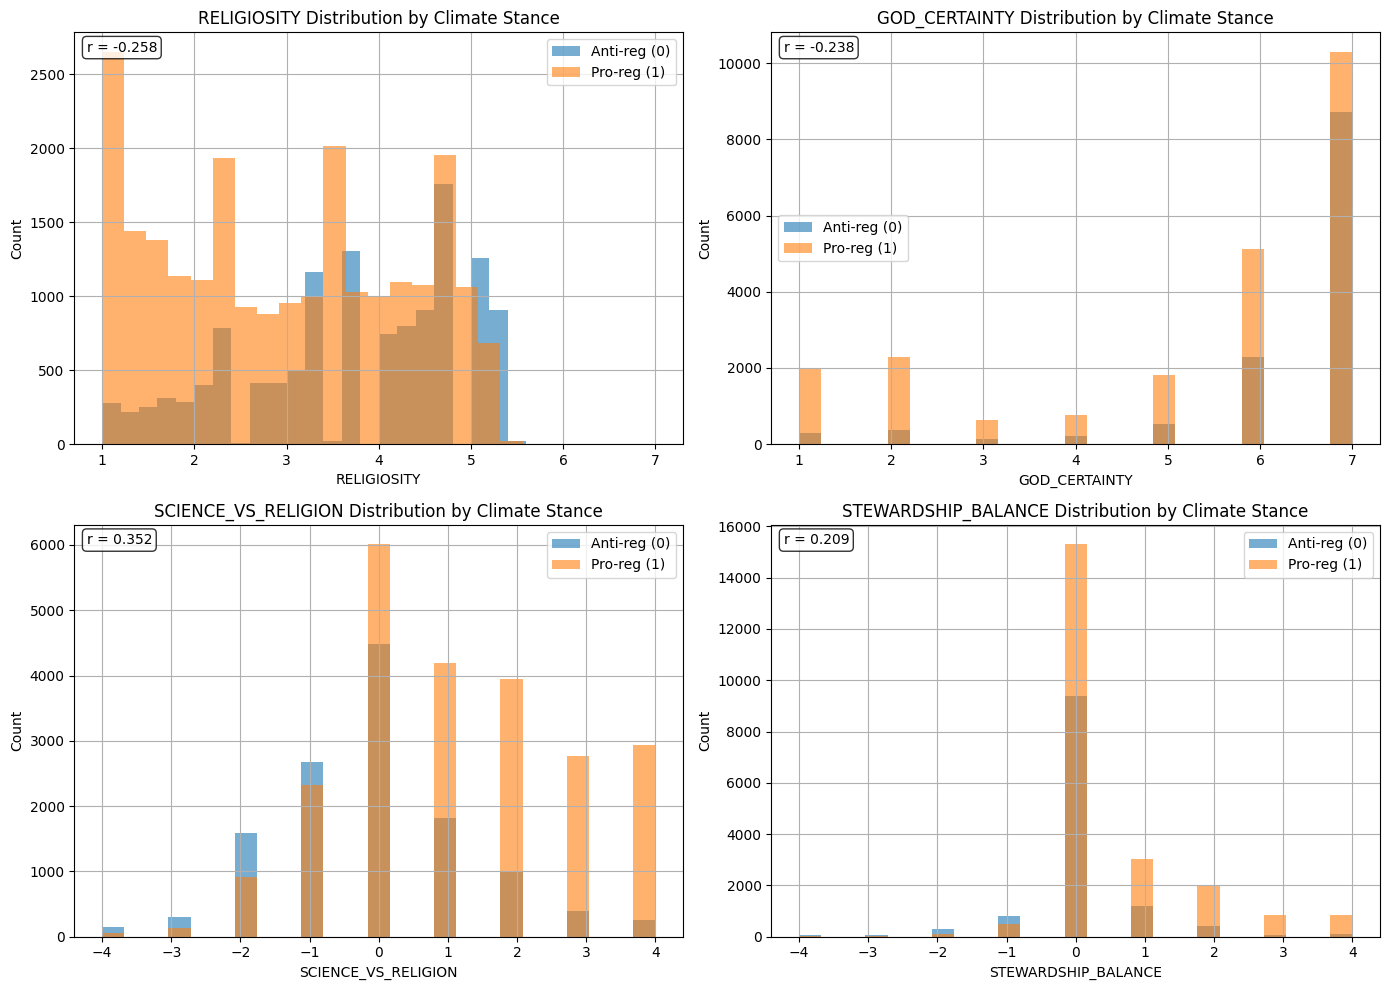

Saved visualization to ../results/02_all_indices.svg


In [74]:
indices = ['RELIGIOSITY', 'GOD_CERTAINTY', 'SCIENCE_VS_RELIGION', 'STEWARDSHIP_BALANCE']
available_indices = [idx for idx in indices if idx in df_clean.columns]

if available_indices and 'QB2C_binary' in df_clean.columns:
    n_indices = len(available_indices)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, idx in enumerate(available_indices):
        ax = axes[i]

        for label, group in df_clean.groupby('QB2C_binary'):
            group[idx].dropna().hist(
                alpha=0.6, bins=25, ax=ax,
                label='Pro-reg (1)' if label == 1 else 'Anti-reg (0)'
            )

        ax.set_xlabel(idx)
        ax.set_ylabel('Count')
        ax.set_title(f'{idx} Distribution by Climate Stance')
        ax.legend()

        corr = df_clean[[idx, 'QB2C_binary']].corr().loc[idx, 'QB2C_binary']
        ax.text(0.02, 0.98, f'r = {corr:.3f}',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    for i in range(len(available_indices), 4):
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('../results/02_all_indices.svg', bbox_inches='tight')
    plt.show()
    print(f"Saved visualization to ../results/02_all_indices.svg")


### **7. Train Test Split**
- Dropping NAs in Class variable
- Train-Test split

In [75]:
### Train Test-Split
from sklearn.model_selection import train_test_split

data_len = len(df_clean)
print("df_clean rows before dropping NAs for QB2C_binary:", data_len)
df_clean = df_clean.dropna(subset=['QB2C_binary'])
print("df_clean rows after dropping NAs for QB2C_binary:", len(df_clean), 
      "\n removed rows", data_len - len(df_clean.dropna(subset=['QB2C_binary'])))

#Train-test split with stratification at class variable
df_train, df_test= train_test_split(
    df_clean,
    test_size=0.2, random_state=68169, stratify=df_clean['QB2C_binary'])

print(f"\nTraining set: {len(df_train)} rows, share: {len(df_train)/len(df_clean)}")
print(f"Value 1 in Training set: {df_train['QB2C_binary'].value_counts()[1]}, share: {round(df_train['QB2C_binary'].value_counts()[1]/len(df_train), 3)}")
print(f"Value 0 in Training set: {df_train['QB2C_binary'].value_counts()[0]}, share: {round(df_train['QB2C_binary'].value_counts()[0]/len(df_train), 3)}")

print(f"\nTest set: {len(df_test)} rows, share: {len(df_test)/len(df_clean)}")
print(f"Value 1 in Training set: {df_test['QB2C_binary'].value_counts()[1]}, share: {round(df_test['QB2C_binary'].value_counts()[1]/len(df_test), 3)}")
print(f"Value 0 in Training set: {df_test['QB2C_binary'].value_counts()[0]}, share: {round(df_test['QB2C_binary'].value_counts()[0]/len(df_test), 3)}")


df_clean rows before dropping NAs for QB2C_binary: 36893
df_clean rows after dropping NAs for QB2C_binary: 36110 
 removed rows 783

Training set: 28888 rows, share: 0.8
Value 1 in Training set: 18687, share: 0.647
Value 0 in Training set: 10201, share: 0.353

Test set: 7222 rows, share: 0.2
Value 1 in Training set: 4672, share: 0.647
Value 0 in Training set: 2550, share: 0.353


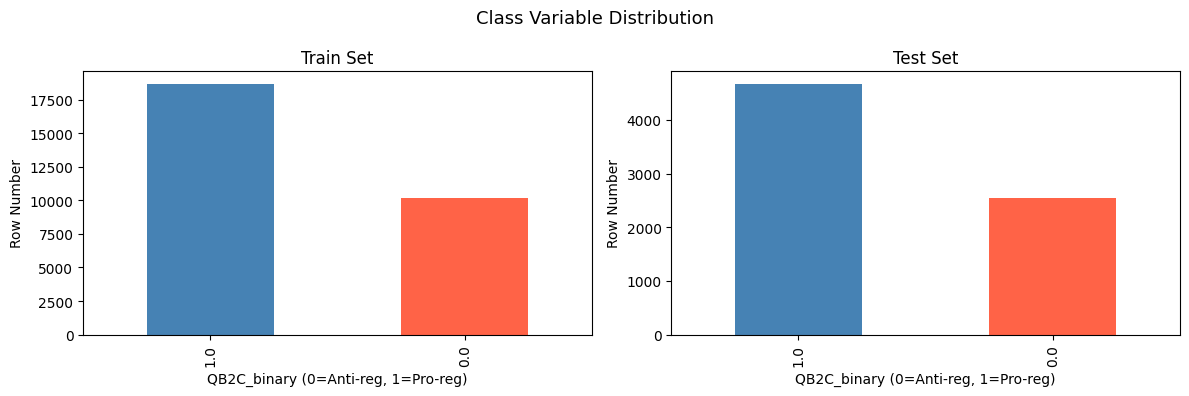

In [76]:
#plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_train['QB2C_binary'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato','gray'])
axes[0].set_title('Train Set')
axes[0].set_ylabel('Row Number')
axes[0].set_xlabel('QB2C_binary (0=Anti-reg, 1=Pro-reg)')

df_test['QB2C_binary'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue','tomato','gray'])
axes[1].set_title('Test Set')
axes[1].set_ylabel('Row Number')
axes[1].set_xlabel('QB2C_binary (0=Anti-reg, 1=Pro-reg)')

plt.suptitle('Class Variable Distribution', fontsize=13)
plt.tight_layout()
plt.show()


### 8. Imputing variables 

#### 8.1 Inspecting missingness
Before encoding categorical Variables, we have to compute how many observations in our df have NAs as our models can't handle this.

In [77]:
def count_rows_with_na(df):
    rows_with_na = df.isna().any(axis=1)
    count = rows_with_na.sum()
    pct = rows_with_na.mean()
    return count, pct

In [78]:
count, pct = count_rows_with_na(df_train)
print(f"Number of rows with NAs: {count} ({pct:.2%})")

Number of rows with NAs: 15116 (52.33%)


Inspect percentage of missingness per variable:

In [79]:
with pd.option_context('display.max_rows', None):
    missing_count = df_train.isna().sum()
    missing_pct = (missing_count / len(df_train) * 100).round(2)

    missing_df = pd.DataFrame({
        'missing_count': missing_count,
        'missing_pct': missing_pct
    }).sort_values(by='missing_pct', ascending=False)

    print(missing_df.head(100))

                     missing_count  missing_pct
CLIM1A                        4751        16.45
RELCON_C                      3867        13.39
RELCON_D                      3838        13.29
RELCON_E                      3714        12.86
RELCON_A                      3497        12.11
INC_SDT1                      2137         7.40
RELCON_B                      2130         7.37
HLL                           1129         3.91
RELINST_A                     1086         3.76
HVN                            972         3.36
IDEO                           955         3.31
CHRNAT                         946         3.27
RELINST_B                      876         3.03
RELINST_E                      859         2.97
RELINST_D                      845         2.93
STEWARDSHIP_BALANCE            840         2.91
SCRLCON1                       825         2.86
GOVSIZE1                       779         2.70
EVOL                           776         2.69
POLITICAL_ATTITUDE             761      

In [80]:
len(missing_df)

102

#### **Diagnostic**

- **CLIM1A (16.45% missing)**  
  This is likely due to the ambiguous nature of the four answer categories, which may have confused participants. Because of the high missingness, the ambiguity of the responses, and its thematic closeness to our class variable, we drop this variable.

- **RELCON_A – RELCON_E (7–13% missing)**  
  The question ("Aside from religion, do you consider yourself to be Jewish/Buddhist/Muslim etc.?") may have confused or annoyed participants, which could explain the relatively high missingness. Since we already measure religious affiliation using **CURREL_NEW** and the variables are highly correlated with their corresponding value, we drop these variables.

- **Income (7.4% missing)**  
  Due to the sensitive nature of this question, we do not assume the data is missing at random (MAR). Instead, it is common in social science that individuals with very high or very low income are less likely to report it, which corresponds to a Missing Not At Random (MNAR) mechanism.  
  Because of this, we cannot reliably impute income based on the observed data, as the missing values are likely systematically different. Properly handling MNAR would require modeling the missingness process, which is beyond the scope of this analysis. Therefore, we drop the income variable entirely rather than attempting to recover it.

- **Remaining variables (0.18% – 3.91% missing)**  
  We are left with many predictors with missingness between 0.18 and 3.9 percent. Since missingness is low and assumed to be Missing At Random (MAR), we impute the remaining values using:
  - mean imputation for ordinal variables  
  - mode imputation for nominal variables

In [81]:
## Checking correlation betwen RELCON and relgious affiliation in CURREL_NEW
corr_value = df_train['RELCON_A'].corr((df_train['CURREL_NEW'] == 50000).astype(int))
print(f"Correlation JEWISH: {corr_value:.4f}")

corr_value = df_train['RELCON_B'].corr((df_train['CURREL_NEW'] == 10000).astype(int))
print(f"Correlation: CATHOLIC {corr_value:.4f}")

corr_value = df_train['RELCON_C'].corr((df_train['CURREL_NEW'] == (80000)).astype(int))
print(f"Correlation HINDU: {corr_value:.4f}")

corr_value = df_train['RELCON_D'].corr((df_train['CURREL_NEW'] == 60000).astype(int))
print(f"Correlation MUSLIM: {corr_value:.4f}")


Correlation JEWISH: 0.6600
Correlation: CATHOLIC 0.8215
Correlation HINDU: 0.7021
Correlation MUSLIM: 0.7220


#### 8.2 Drop variables from Train and Test Set

In [82]:
cols_to_drop = ['RELCON_A', 'RELCON_B', 'RELCON_C', 'RELCON_D', 'RELCON_E', 'CLIM1A', 'INC_SDT1', 'FRMREL']

for name, df in [("df_train", df_train), ("df_test", df_test)]:
    actually_dropped = [col for col in cols_to_drop if col in df.columns]
    if actually_dropped:
        print(f"{name} — dropped: {actually_dropped}")
    else:
        print(f"{name} — no columns to drop, already removed.")

df_train = df_train.drop(columns=cols_to_drop, errors='ignore')
df_test  = df_test.drop(columns=cols_to_drop,  errors='ignore')


df_train — dropped: ['RELCON_A', 'RELCON_B', 'RELCON_C', 'RELCON_D', 'RELCON_E', 'CLIM1A', 'INC_SDT1', 'FRMREL']
df_test — dropped: ['RELCON_A', 'RELCON_B', 'RELCON_C', 'RELCON_D', 'RELCON_E', 'CLIM1A', 'INC_SDT1', 'FRMREL']


#### 8.3 Fit Imputer on Train Set and Transform Train & Test Set

In [83]:
values_without_na = ["REG", "QB2C_binary", "RELIGIOSITY"]
nominal_vars = ["CHNG_A", "CHNG_B", "CHNG_C", "DIVRELPOP", "DIVRACPOP","POORASSIST", "SCIMPACT", "RELIMPACT", "EVOL",
                "CURREL_NEW", "POLITICAL_ATTITUDE", "SECMEMB","LIFEDIR", "LIFESPIR", "MARITAL", "RACECMB", "EMPLSIT","USGEN", "GENDER"]
ordinal_vars = [col for col in df_train.columns
        if col not in nominal_vars + values_without_na]


In [84]:
median_imputer = SimpleImputer(strategy="median")   # for ordinal
mode_imputer   = SimpleImputer(strategy="most_frequent")  # for nominal

# Fit & transform on train set 
df_train[ordinal_vars]  = median_imputer.fit_transform(df_train[ordinal_vars])
df_train[nominal_vars]  = mode_imputer.fit_transform(df_train[nominal_vars])

# Apply to test set (transform only)
df_test[ordinal_vars]   = median_imputer.transform(df_test[ordinal_vars])
df_test[nominal_vars]   = mode_imputer.transform(df_test[nominal_vars])

In [ ]:
# --- Missing value check ---
train_na = df_train[ordinal_vars + nominal_vars].isnull().sum()
test_na  = df_test[ordinal_vars + nominal_vars].isnull().sum()

print("=== Remaining NaNs in train ===")
print(train_na[train_na > 0] if train_na.any() else "None — all imputed ✓")

print("\n=== Remaining NaNs in test ===")
print(test_na[test_na > 0] if test_na.any() else "None — all imputed ✓")

# --- Shape sanity check ---
print(f"\ndf_train shape: {df_train.shape}")
print(f"df_test shape:  {df_test.shape}")
assert df_train.shape[1] == df_test.shape[1], "Column count mismatch between train and test!"


=== Remaining NaNs in train ===
None — all imputed ✓

=== Remaining NaNs in test ===
None — all imputed ✓

df_train shape: (28887, 94)
df_test shape:  (7222, 94)
